In [175]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn import metrics

import warnings
warnings.filterwarnings('ignore')

In [134]:
import yfinance as yf

tesla_ticker = yf.Ticker("TSLA")
latest_data = tesla_ticker.history(period="10y")

# Save the DataFrame to a CSV file with date information preserved
latest_data.to_csv("tesla_stock_data.csv", index=True, date_format="%Y-%m-%d")

In [135]:
df = pd.read_csv('tesla_stock_data.csv')
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2015-09-21,17.598667,18.104668,17.053333,17.613333,91803000,0.0,0.0
1,2015-09-22,17.268667,17.510000,17.058001,17.396000,54966000,0.0,0.0
2,2015-09-23,17.463333,17.472000,17.172001,17.403999,39012000,0.0,0.0
3,2015-09-24,17.302000,17.563334,17.080667,17.541332,51723000,0.0,0.0
4,2015-09-25,17.774000,17.794001,17.076668,17.127333,56601000,0.0,0.0


In [136]:
df.shape

(2515, 8)

In [137]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,2515.000000,2515.000000,2515.000000,2515.000000,2.515000e+03,2515.0,2515.000000
mean,137.637708,140.710794,134.371537,137.613076,1.148478e+08,0.0,0.003181
std,122.946376,125.711395,119.926239,122.856482,7.323263e+07,0.0,0.116250
min,9.488000,10.331333,9.403333,9.578000,1.062000e+07,0.0,0.000000
25%,19.854333,20.239666,19.466666,19.844000,7.000800e+07,0.0,0.000000
50%,126.983330,132.996674,123.007332,126.786667,9.577080e+07,0.0,0.000000
75%,240.676666,246.615005,235.350006,240.474998,1.324928e+08,0.0,0.000000
max,475.899994,488.540009,457.510010,479.859985,9.140820e+08,0.0,5.000000


In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2515 entries, 0 to 2514
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          2515 non-null   object 
 1   Open          2515 non-null   float64
 2   High          2515 non-null   float64
 3   Low           2515 non-null   float64
 4   Close         2515 non-null   float64
 5   Volume        2515 non-null   int64  
 6   Dividends     2515 non-null   float64
 7   Stock Splits  2515 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 157.3+ KB


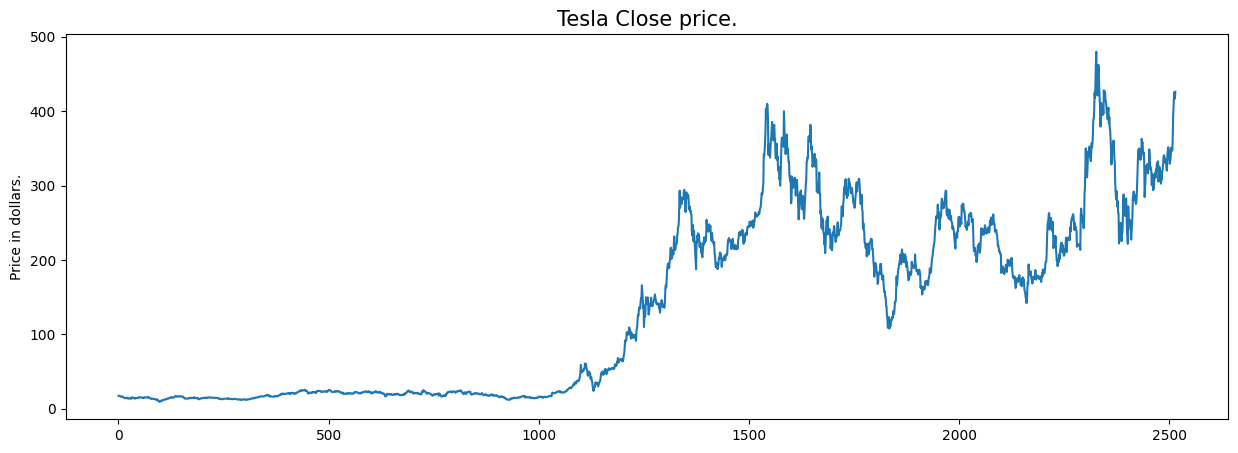

In [159]:
plt.figure(figsize=(15, 5))
plt.plot(df["Close"])
plt.title("Tesla Close price.", fontsize=15)
plt.ylabel("Price in dollars.")
plt.show()

In [140]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2015-09-21,17.598667,18.104668,17.053333,17.613333,91803000,0.0,0.0
1,2015-09-22,17.268667,17.510000,17.058001,17.396000,54966000,0.0,0.0
2,2015-09-23,17.463333,17.472000,17.172001,17.403999,39012000,0.0,0.0
3,2015-09-24,17.302000,17.563334,17.080667,17.541332,51723000,0.0,0.0
4,2015-09-25,17.774000,17.794001,17.076668,17.127333,56601000,0.0,0.0


In [141]:
df = df.drop(['Dividends'], axis=1)

In [142]:
df = df.drop(['Stock Splits'], axis=1)

In [143]:
df.head()

,Date,Open,High,Low,Close,Volume
0,2015-09-21,17.598667,18.104668,17.053333,17.613333,91803000
1,2015-09-22,17.268667,17.510000,17.058001,17.396000,54966000
2,2015-09-23,17.463333,17.472000,17.172001,17.403999,39012000
3,2015-09-24,17.302000,17.563334,17.080667,17.541332,51723000
4,2015-09-25,17.774000,17.794001,17.076668,17.127333,56601000


In [144]:
df.tail()

,Date,Open,High,Low,Close,Volume
2510,2025-09-15,423.130005,425.700012,402.429993,410.040009,163823700
2511,2025-09-16,414.500000,423.250000,411.429993,421.619995,104285700
2512,2025-09-17,415.750000,428.309998,409.670013,425.859985,106133500
2513,2025-09-18,428.869995,432.220001,416.559998,416.850006,90454500
2514,2025-09-19,421.820007,429.470001,421.720001,426.070007,92847900


In [145]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

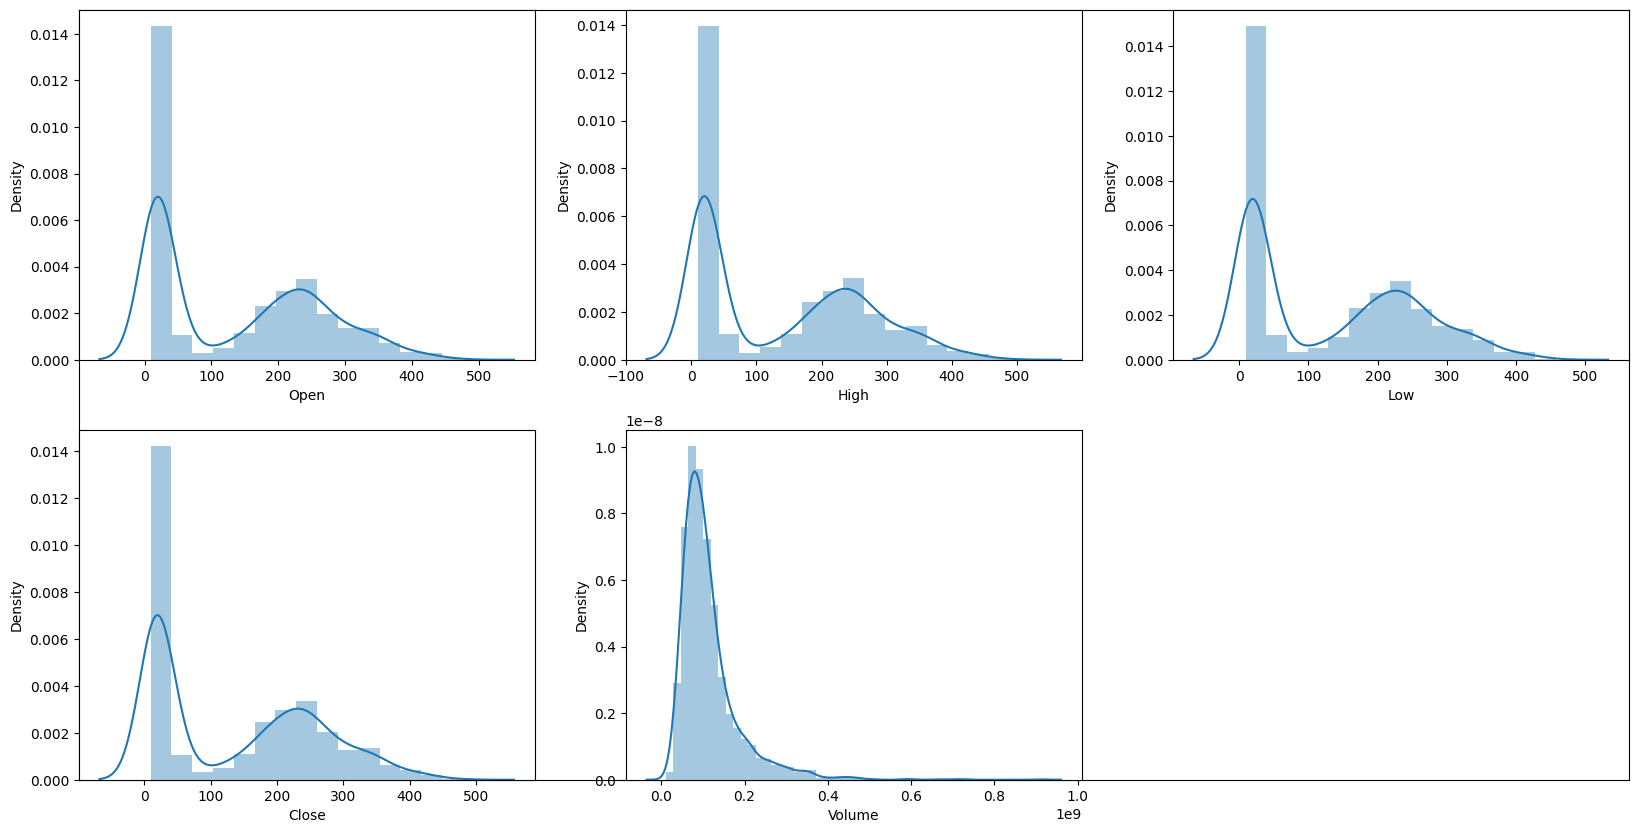

In [164]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.subplots(figsize=(20,10))
plt.yticks([])
plt.xticks([])

for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sb.distplot(df[col])
plt.show()

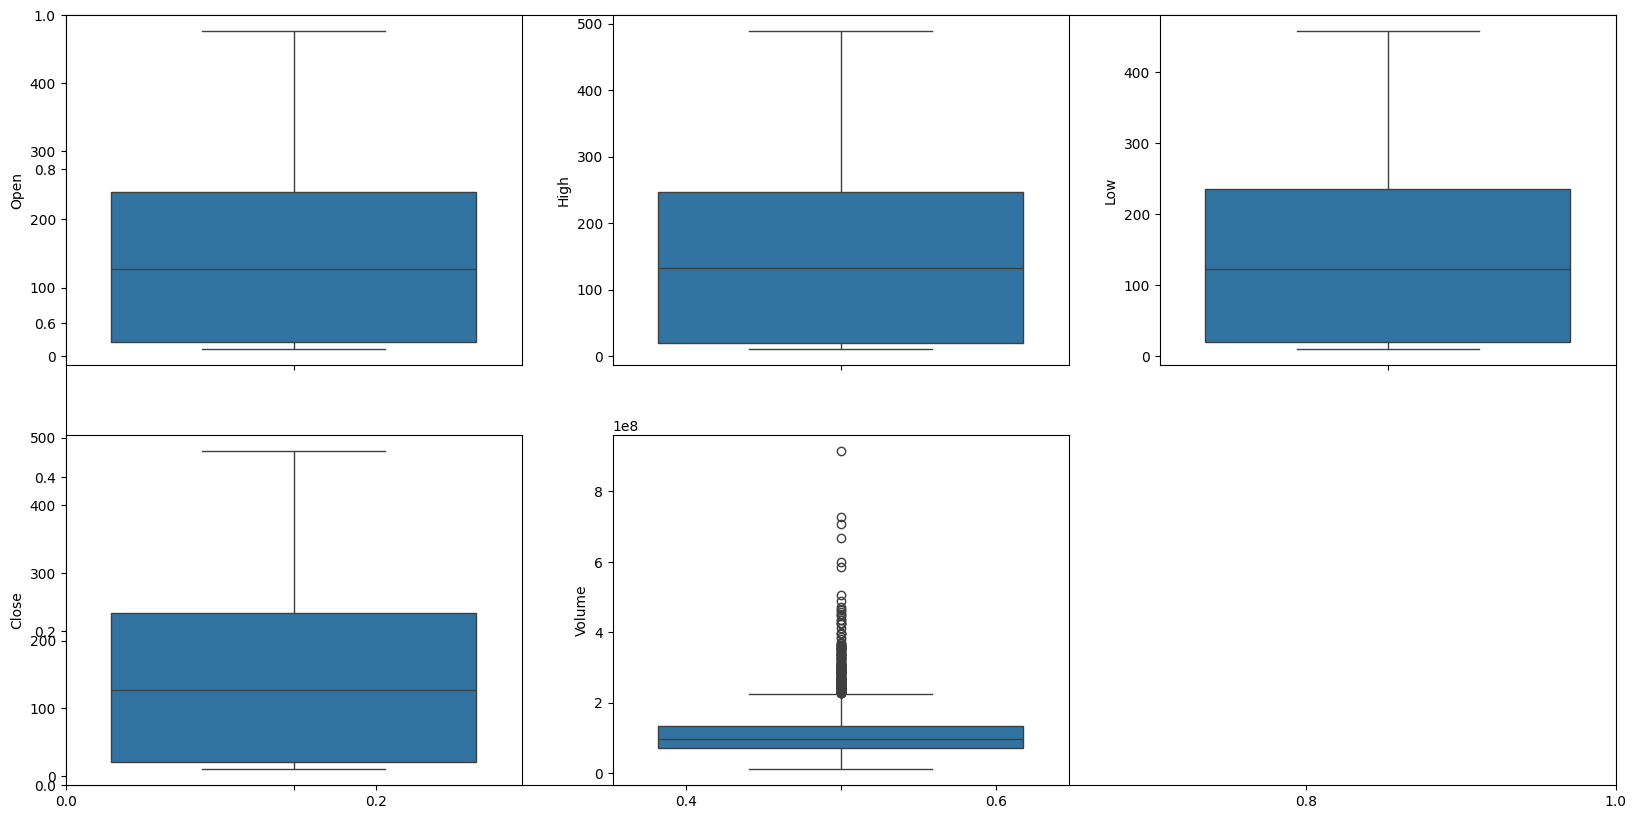

In [165]:
plt.subplots(figsize=(20, 10))
for i, col in enumerate(features):
    plt.subplot(2, 3, i+1)
    sb.boxplot(df[col])
plt.show()

In [148]:
# Feature Engineering
splitted = df['Date'].str.split('-', expand=True)

df['day'] = splitted[2].astype('int')
df['month'] = splitted[1].astype('int')
df['year'] = splitted[0].astype('int')

df.head()

,Date,Open,High,Low,Close,Volume,day,month,year
0,2015-09-21,17.598667,18.104668,17.053333,17.613333,91803000,21,9,2015
1,2015-09-22,17.268667,17.510000,17.058001,17.396000,54966000,22,9,2015
2,2015-09-23,17.463333,17.472000,17.172001,17.403999,39012000,23,9,2015
3,2015-09-24,17.302000,17.563334,17.080667,17.541332,51723000,24,9,2015
4,2015-09-25,17.774000,17.794001,17.076668,17.127333,56601000,25,9,2015


In [149]:
df['is_quarter_end'] = np.where(df['month']%3==0, 1, 0)
df.tail()

,Date,Open,High,Low,Close,Volume,day,month,year,is_quarter_end
2510,2025-09-15,423.130005,425.700012,402.429993,410.040009,163823700,15,9,2025,1
2511,2025-09-16,414.500000,423.250000,411.429993,421.619995,104285700,16,9,2025,1
2512,2025-09-17,415.750000,428.309998,409.670013,425.859985,106133500,17,9,2025,1
2513,2025-09-18,428.869995,432.220001,416.559998,416.850006,90454500,18,9,2025,1
2514,2025-09-19,421.820007,429.470001,421.720001,426.070007,92847900,19,9,2025,1


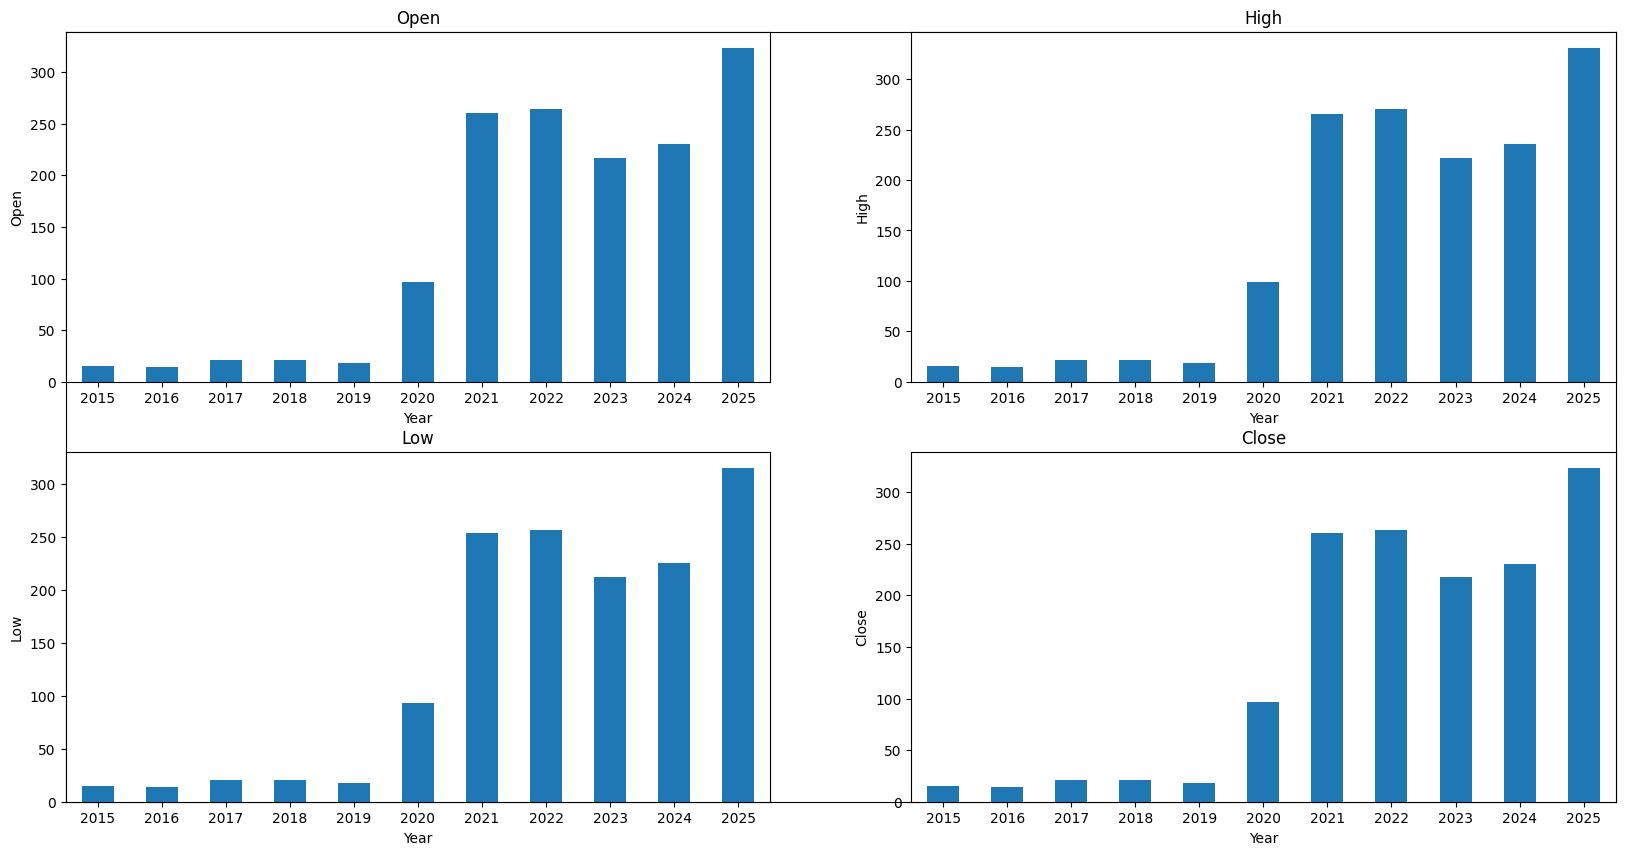

In [150]:
data_grouped = df.drop('Date', axis=1).groupby('year').mean()

plt.subplots(figsize=(20, 10))
plt.yticks([])
plt.xticks([])

for i, col in enumerate(['Open', 'High', 'Low', 'Close']):
    plt.subplot(2, 2, i+1)
    data_grouped[col].plot.bar()   
    plt.xticks(rotation=0)
    plt.title(col)

    plt.xlabel('Year')
    plt.ylabel(col)
plt.show()

In [151]:
df.drop('Date', axis=1).groupby('is_quarter_end').mean()

,Open,High,Low,Close,Volume,day,month,year
is_quarter_end,,,,,,,,
0,136.905173,139.951587,133.669777,136.864775,1.153624e+08,15.711722,6.097488,2020.248804
1,139.090611,142.216599,135.763402,139.097250,1.138272e+08,15.785291,7.437722,2020.137604


In [152]:
df['open-close'] = df['Open'] - df['Close']
df['low-high'] = df['Low'] - df['High']
df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

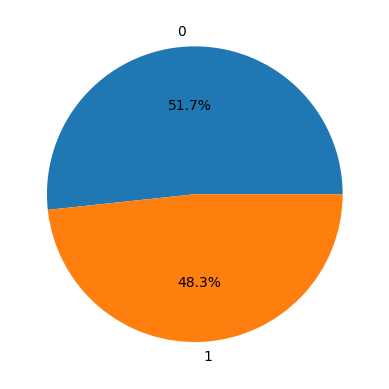

In [153]:
plt.pie(df['target'].value_counts().values, labels=[0, 1], autopct='%1.1f%%')
plt.show()

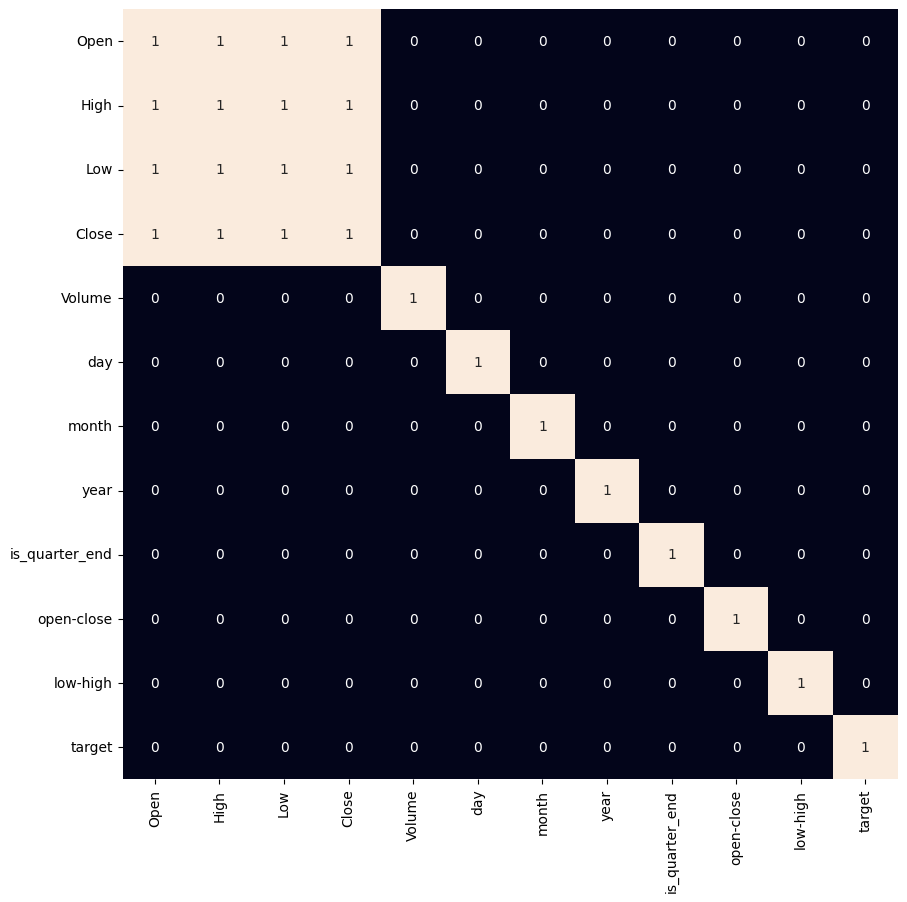

In [167]:
plt.figure(figsize=(10, 10))

sb.heatmap(df.drop('Date', axis=1).corr() > 0.9, annot=True, cbar=False)
plt.show()

In [155]:
# Data splitting and normalization
features = df[['open-close', 'low-high', 'is_quarter_end']]
target = df['target']

scaler = StandardScaler()
features = scaler.fit_transform(features)

X_train, X_valid, Y_train, Y_valid = train_test_split(features, target, test_size=0.1, random_state=2022)
print(X_train.shape, X_valid.shape)

(2263, 3) (252, 3)


In [182]:
# Model development and evaluation
models = [LogisticRegression(), SVC(kernel='poly', probability=True), XGBClassifier()]

# Add polynomial regression model
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_valid_poly = poly.transform(X_valid)
poly_reg = LinearRegression()
models.append(poly_reg)

for i in range(4):
    models[i].fit(X_train, Y_train)
    
    print(f'{models[i]} : ')
    if hasattr(models[i], 'predict_proba'):
        print("training Accuracy : ", metrics.roc_auc_score(Y_valid, models[i].predict_proba(X_valid)[:, 1]))
        print('Validation Accuracy : ', metrics.roc_auc_score(Y_valid, models[i].predict_proba(X_valid)[:, 1]))
    else:
        y_pred = models[i].predict(X_valid)
        print("R-squared : ", models[i].score(X_valid, Y_valid))
    
    print()


LogisticRegression() : 
training Accuracy :  0.50875086876856
Validation Accuracy :  0.50875086876856

SVC(kernel='poly', probability=True) : 
training Accuracy :  0.4824034877108738
Validation Accuracy :  0.4824034877108738

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
training A

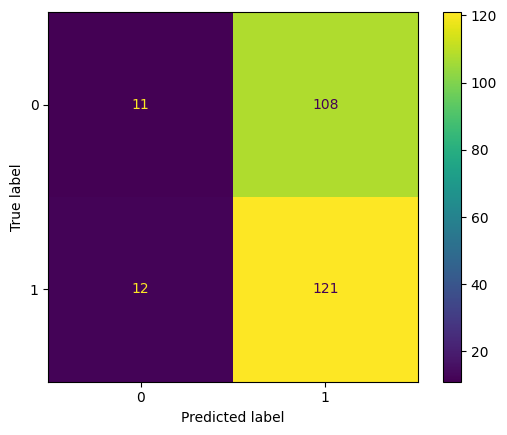

In [184]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(models[0], X_valid, Y_valid)
plt.show()

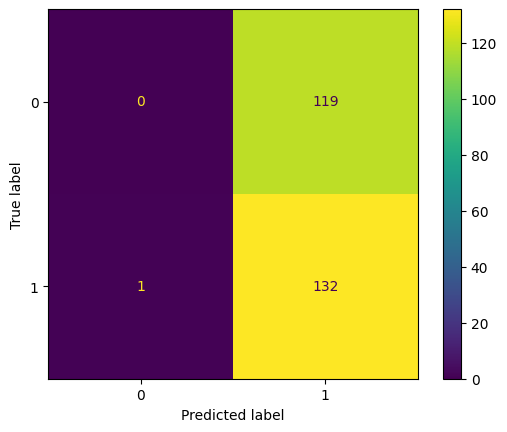

In [169]:
ConfusionMatrixDisplay.from_estimator(models[1], X_valid, Y_valid)
plt.show()

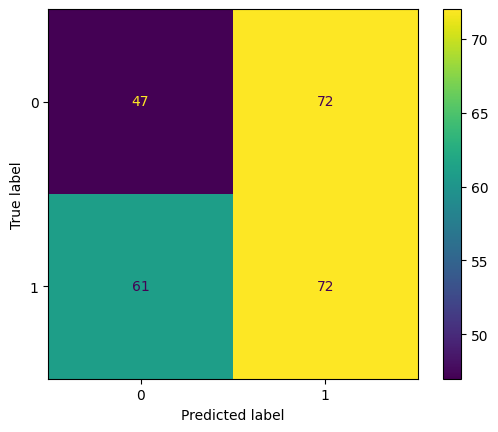

In [170]:
ConfusionMatrixDisplay.from_estimator(models[2], X_valid, Y_valid)
plt.show()